# Crop Yield Estimation — Improved Multimodal Model

**Dataset:** [CropNet](https://github.com/fudong03/CropNet) — Sentinel-2 imagery + HRRR weather + USDA yields. CC BY-NC license, research-only.

**Task:** Predict county-level corn yield (BU/acre) for the held-out test counties.

## 0) Runtime Setup

**Runtime → Change runtime type → GPU** before running. ResNet18 + ~5k samples trains in a few minutes on a T4.

In [ ]:
# Install dependencies. libeccodes is required by pygrib (HRRR weather files
# are in GRIB format). cropnet is the official package wrapping the dataset.
!apt-get install -q -y libeccodes-dev
%pip install -q pygrib cropnet

import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    !nvidia-smi -L

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  libeccodes-data libeccodes0
The following NEW packages will be installed:
  libeccodes-data libeccodes-dev libeccodes0
0 upgraded, 3 newly installed, 0 to remove and 42 not upgraded.
Need to get 3,076 kB of archives.
After this operation, 60.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes-data all 2.24.2-1 [1,592 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes0 amd64 2.24.2-1 [614 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes-dev amd64 2.24.2-1 [870 kB]
Fetched 3,076 kB in 0s (11.6 MB/s)
Selecting previously unselected package libeccodes-data.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libeccodes-data_2.24.2-1_all.deb ...
Unpacking libeccodes-data (2.24.2-1) ...
Selecting previ

In [ ]:
# ---------------------------------------------------------------------------
# Reproducibility: seed everything that has a random component.
# ---------------------------------------------------------------------------
# ML experiments are pseudo-random — they use random number generators for
# weight initialization, dataset shuffling, dropout, etc. Without fixed seeds,
# you get a different result every run, which makes debugging miserable
# ("did my change help, or did I just get lucky this time?").
#
# We seed all four sources of randomness our code touches:
#   - Python's built-in `random`      (used by some libraries internally)
#   - NumPy                            (used by our dataset code)
#   - PyTorch (CPU)                    (weight init, DataLoader shuffling)
#   - PyTorch (CUDA)                   (GPU operations)

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Also seed PyTorch DataLoader workers so shuffle order is reproducible.
def seed_worker(worker_id):
    """Called by DataLoader to seed each worker process."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"All random seeds set to {SEED}")


All random seeds set to 42


## 1) Download Data — `DataDownloader`

Downloads three modalities from CropNet servers and HuggingFace:


In [ ]:
# ---------------------------------------------------------------------------
# Pandas 3.x compatibility patch for cropnet's DataDownloader.
# ---------------------------------------------------------------------------
# DataDownloader was written against pandas 2.x, where pd.read_json() accepted
# raw JSON strings. Pandas 3.x deprecated this and now requires a file-like
# object (StringIO). Without this patch, downloads crash with a TypeError.
#
# We monkey-patch pd.read_json to wrap raw JSON strings in StringIO before
# passing them through. The `_cropnet_patched` flag prevents double-patching
# if this cell is re-run.
# ---------------------------------------------------------------------------
import io
import pandas as pd

if not getattr(pd, '_cropnet_patched', False):
    _orig_read_json = pd.read_json

    def _patched_read_json(path_or_buf, *args, **kwargs):
        # If the input looks like a JSON literal (starts with { or [),
        # wrap it in StringIO so pandas 3.x accepts it.
        if isinstance(path_or_buf, str) and path_or_buf.lstrip().startswith(("{", "[")):
            path_or_buf = io.StringIO(path_or_buf)
        return _orig_read_json(path_or_buf, *args, **kwargs)

    pd.read_json = _patched_read_json
    pd._cropnet_patched = True
    print("pd.read_json patched for pandas 3.x compatibility")


In [ ]:
# ---------------------------------------------------------------------------
# Configuration: which counties, which years, which crop.
# ---------------------------------------------------------------------------
from cropnet.data_downloader import DataDownloader
from huggingface_hub import hf_hub_download
import os, shutil

TARGET_DIR = "/content/cropnet_data"
CROP       = "Corn"

# Train counties span 5 states in the US Corn Belt.
FIPS_TRAIN = ["17019", "17043", "19013", "19015", "26065", "18019", "39003"]
# Test counties: held-out geography in IL, IA, OH.
FIPS_TEST  = ["17115", "19163", "39101"]
FIPS_ALL   = FIPS_TRAIN + FIPS_TEST
YEARS      = ["2021", "2022"]
HISTORICAL_YEARS = [str(y) for y in range(2010, int(YEARS[0]))]

# --- USDA yield records ------------------------------------------------------
downloader = DataDownloader(target_dir=TARGET_DIR)
downloader.download_USDA(CROP, fips_codes=FIPS_ALL, years=YEARS)

print("Downloading historical USDA data...")
for y in HISTORICAL_YEARS:
    try:
        downloader.download_USDA(CROP, fips_codes=FIPS_ALL, years=[y])
    except TypeError:
        print(f"Skipping year {y}: not supported by cropnet USDA mapping.")

# --- HRRR weather (Pre-computed from Hugging Face) ---------------------------
# Instead of downloading raw hourly GRIB files, we download the daily
# pre-computed summaries directly from the CropNet Hugging Face repo.
STATE_MAP = {"17": "IL", "18": "IN", "19": "IA", "26": "MI", "39": "OH"}
state_codes = sorted({f[:2] for f in FIPS_ALL})

print("Checking pre-computed weather downloads...")
MONTHS = [f"{m:02d}" for m in range(1, 13)]
for sc in state_codes:
    abbr = STATE_MAP[sc]
    for year in YEARS:
        for month in MONTHS:
            fname = f"HRRR_{sc}_{abbr}_{year}-{month}.csv"
            hf_path = f"WRF-HRRR Computed Dataset/data/{year}/{abbr}/{fname}"
            local_path = os.path.join(TARGET_DIR, "WRF-HRRR Computed Dataset", "data", year, abbr, fname)
            if not os.path.exists(local_path):
                os.makedirs(os.path.dirname(local_path), exist_ok=True)
                try:
                    tmp = hf_hub_download(
                        repo_id="CropNet/CropNet", repo_type="dataset",
                        filename=hf_path, local_dir="/tmp/hf_weather"
                    )
                    shutil.move(tmp, local_path)
                    print(f"Downloaded pre-computed weather: {fname}")
                except Exception as e:
                    # Some files might genuinely be missing on the repo
                    pass

# --- Sentinel-2 imagery (from HuggingFace) -----------------------------------
QUARTERS  = [("01-01", "03-31"), ("04-01", "06-30"),
             ("07-01", "09-30"), ("10-01", "12-31")]

total = len(state_codes) * len(YEARS) * len(QUARTERS)
done = 0

for sc in state_codes:
    abbr = STATE_MAP[sc]
    for year in YEARS:
        for qs, qe in QUARTERS:
            fname      = f"Agriculture_{sc}_{abbr}_{year}-{qs}_{year}-{qe}.h5"
            hf_path    = f"Sentinel-2 Imagery/data/AG/{year}/{abbr}/{fname}"
            local_path = os.path.join(TARGET_DIR, "Sentinel", "data", "AG", year, abbr, fname)
            done += 1
            if os.path.exists(local_path):
                print(f"[{done}/{total}] already exists: {fname}")
                continue
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            try:
                tmp = hf_hub_download(
                    repo_id="CropNet/CropNet", repo_type="dataset",
                    filename=hf_path, local_dir="/tmp/hf_s2"
                )
                shutil.move(tmp, local_path)
                print(f"[{done}/{total}] downloaded: {fname}")
            except Exception as e:
                print(f"[{done}/{total}] FAILED {fname}: {e}")

print("Download complete:", TARGET_DIR)

Progress: [ 1/2 ], Downloading USDA Data, Year: 2021, Crop: Corn
Progress: [ 2/2 ], Downloading USDA Data, Year: 2022, Crop: Corn
Progress: [ 1/1 ], Downloading USDA Data, Year: 2010, Crop: Corn
Skipping year 2010: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2011, Crop: Corn
Skipping year 2011: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2012, Crop: Corn
Skipping year 2012: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2013, Crop: Corn
Skipping year 2013: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2014, Crop: Corn
Skipping year 2014: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2015, Crop: Corn
Skipping year 2015: not supported by cropnet USDA mapping.
Progress: [ 1/1 ], Downloading USDA Data, Year: 2016, Crop: Corn
Progress: [ 1/1 ], Downloading USDA Data, Year: 2017, Crop: C

## 2) Multimodal Dataset — Satellite + Weather + Yield

In [ ]:
# ---------------------------------------------------------------------------
# MultimodalCropDataset
# ---------------------------------------------------------------------------
# A PyTorch Dataset that returns (image_sequence, weather_features, yield)
# for each sample. Now includes a Historical Yield Baseline parameter!
# ---------------------------------------------------------------------------
import numpy as np
import torch
import pandas as pd
import os
import glob
from torch.utils.data import Dataset
from cropnet.data_retriever import DataRetriever


def _retrieve_weather_custom(base_dir, fips_codes, years):
    """
    Custom weather retriever that reads the pre-computed daily summaries directly
    from the WRF-HRRR Computed Dataset directory we downloaded them to.
    """
    weather_dict = {}
    state_map = {"17": "IL", "18": "IN", "19": "IA", "26": "MI", "39": "OH"}

    for fips in fips_codes:
        sc = fips[:2]
        if sc not in state_map:
            continue
        abbr = state_map[sc]

        weather_dict[fips] = {}
        for year in years:
            year_dfs = []
            for month in range(1, 13):
                fname = f"HRRR_{sc}_{abbr}_{year}-{month:02d}.csv"
                path = os.path.join(base_dir, "WRF-HRRR Computed Dataset", "data", year, abbr, fname)
                if os.path.exists(path):
                    try:
                        df = pd.read_csv(path)
                        # Filter for the specific county FIPS
                        county_df = df[df["county_ansi"].astype(str).str.zfill(3) == fips[2:]]
                        if not county_df.empty:
                            # Drop metadata columns to keep only features
                            feat_cols = [c for c in county_df.columns if c not in ("fips", "year", "state_ansi", "county_ansi", "Unnamed: 0")]
                            year_dfs.append(county_df[feat_cols].mean(axis=0).to_numpy(dtype=np.float32))
                    except Exception as e:
                        pass
            if year_dfs:
                # Average the monthly means to get a yearly summary feature vector
                weather_dict[fips][year] = np.mean(year_dfs, axis=0)

    return weather_dict


def _weather_to_vector(weather_data, fips, year, expected_dim=None):
    """
    Convert weather data for one (fips, year) into a fixed-size float vector.
    """
    vec = None

    if fips in weather_data and year in weather_data[fips]:
        vec = weather_data[fips][year]

    # Fallback: zeros (lets the model still train as satellite-only).
    if vec is None:
        vec = np.zeros(expected_dim or 16, dtype=np.float32)

    # Standardize length across samples by pad-or-truncate.
    if expected_dim is not None and len(vec) != expected_dim:
        if len(vec) < expected_dim:
            vec = np.pad(vec, (0, expected_dim - len(vec)))
        else:
            vec = vec[:expected_dim]
    return vec


class MultimodalCropDataset(Dataset):
    """
    Multimodal CropNet dataset returning (image_sequence, weather+history, yield).
    """

    def __init__(self, fips_codes, years, base_dir, crop,
                 transform=None,
                 yield_mean=None, yield_std=None,
                 weather_dim=None):

        self.transform = transform
        retriever = DataRetriever(base_dir=base_dir)

        # Pull all three modalities from disk.
        usda_df  = retriever.retrieve_USDA(crop, fips_codes, years)
        s2_dict  = retriever.retrieve_Sentinel2(fips_codes, years, image_type="AG")
        weather_data = _retrieve_weather_custom(base_dir, fips_codes, years)

        # --- NEW: Get historical yield data ---
        hist_years = [str(y) for y in range(2010, int(years[0]))]
        hist_df = retriever.retrieve_USDA(crop, fips_codes, hist_years)
        self.hist_yields = {}
        if hist_df is not None and not hist_df.empty:
            for i, row in hist_df.iterrows():
                f = str(row["state_ansi"]).zfill(2) + str(row["county_ansi"]).zfill(3)
                if f not in self.hist_yields:
                    self.hist_yields[f] = []
                self.hist_yields[f].append(float(row["YIELD, MEASURED IN BU / ACRE"]))

        # Average it out
        for f in self.hist_yields:
            self.hist_yields[f] = np.mean(self.hist_yields[f])

        global_hist_mean = np.mean(list(self.hist_yields.values())) if self.hist_yields else 150.0
        # --------------------------------------

        raw = []
        seen_weather_lens = []

        # Find the minimum sequence length (T) across all counties
        available_T = [arr.shape[0] for arr in s2_dict.values() if len(arr.shape) == 5]
        min_t = min(available_T) if available_T else 0
        print(f"Truncating all satellite sequences to T={min_t} frames to ensure equal sizing.")

        for _, row in usda_df.iterrows():
            fips = str(row["state_ansi"]).zfill(2) + str(row["county_ansi"]).zfill(3)
            yield_val = float(row["YIELD, MEASURED IN BU / ACRE"])
            year_val  = str(row.get("year", years[0]))

            if fips not in s2_dict:
                continue

            arr = s2_dict[fips].astype(np.float32) / 255.0
            # Enforce identical sequence length by truncating
            arr = arr[:min_t]

            # Calculate the expected dimension for just the weather portion
            # (total weather_dim minus the 1 historical slot)
            w_expected = weather_dim - 1 if weather_dim is not None else None
            wvec = _weather_to_vector(weather_data, fips, year_val, expected_dim=w_expected)

            # --- NEW: Append historical yield vector to weather features ---
            hist_y = self.hist_yields.get(fips, global_hist_mean)
            # Scale by 1/100 to keep it roughly in the range of other features
            hist_feat = np.array([hist_y / 100.0], dtype=np.float32)

            wvec = np.concatenate([wvec, hist_feat])
            # ------------------------------------------------------------

            seen_weather_lens.append(len(wvec))

            for p in range(arr.shape[1]):
                img_seq = torch.from_numpy(arr[:, p]).permute(0, 3, 1, 2)
                w_tensor = torch.from_numpy(wvec).float()
                raw.append((img_seq, w_tensor, yield_val))

        if len(raw) == 0:
            raise RuntimeError("No samples loaded. Check that downloads completed.")

        yields = np.array([y for _, _, y in raw], dtype=np.float32)
        self.yield_mean = float(yields.mean()) if yield_mean is None else yield_mean
        self.yield_std  = float(yields.std())  if yield_std  is None else yield_std
        if self.yield_std < 1e-6:
            self.yield_std = 1.0

        self.weather_dim = max(seen_weather_lens) if seen_weather_lens else 21

        self.samples = [
            (
                img_seq,
                wvec,
                torch.tensor((y - self.yield_mean) / self.yield_std, dtype=torch.float32)
            )
            for img_seq, wvec, y in raw
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_seq, weather, yld = self.samples[idx]
        if self.transform is not None:
            img_seq = self.transform(img_seq)
        return img_seq, weather, yld


print("MultimodalCropDataset defined with Historical Yield Baseline.")

MultimodalCropDataset defined with Historical Yield Baseline.


## 3) Augmentation, Splits, and DataLoaders

In [ ]:
# ---------------------------------------------------------------------------
# Sequence-aware augmentation
# ---------------------------------------------------------------------------
# torchvision.transforms operate on (C, H, W) tensors. Our images are
# (T, C, H, W). We can't just call RandomHorizontalFlip — it would flip
# each frame independently, which would scramble the temporal sequence.
#
# Solution: write a tiny wrapper that decides ONCE per sequence whether
# to flip, then applies that decision to every frame. This preserves the
# temporal coherence of the augmented sequence.
# ---------------------------------------------------------------------------
import torch.nn.functional as F

class SequenceFlipAugment:
    """Random h/v flips applied identically to all frames in a sequence."""

    def __init__(self, p_hflip=0.5, p_vflip=0.5):
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip

    def __call__(self, img_seq):
        # img_seq: (T, C, H, W)
        if torch.rand(1).item() < self.p_hflip:
            img_seq = torch.flip(img_seq, dims=[-1])  # flip width
        if torch.rand(1).item() < self.p_vflip:
            img_seq = torch.flip(img_seq, dims=[-2])  # flip height
        return img_seq

train_augment = SequenceFlipAugment(p_hflip=0.5, p_vflip=0.5)


In [ ]:
# ---------------------------------------------------------------------------
# Build datasets and split into train/val/test.
# ---------------------------------------------------------------------------
# Strategy:
#   - Test set is fully held-out counties (FIPS_TEST), defined upstream.
#   - Validation set is a random 15% of the training samples. This is
#     RANDOM at the sample level (not county level) for simplicity, but
#     since each sample is one patch, val and train still differ in spatial
#     location even though they share counties.
# ---------------------------------------------------------------------------
from torch.utils.data import DataLoader, random_split

# Build full training dataset (will be split into train + val below).
full_train_ds = MultimodalCropDataset(
    fips_codes=FIPS_TRAIN,
    years=YEARS,
    base_dir=TARGET_DIR,
    crop=CROP,
    transform=train_augment,    # augmentation ON for train
)

# Random 85/15 split on training samples.
val_size   = int(0.15 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),  # reproducible split
)

# Test dataset uses train's normalization stats (CRITICAL for fair evaluation).
# Without this, the model would be predicting on a differently-scaled target
# than what it trained on, which is the standard data leakage trap students
# fall into.
test_ds = MultimodalCropDataset(
    fips_codes=FIPS_TEST,
    years=YEARS,
    base_dir=TARGET_DIR,
    crop=CROP,
    transform=None,                            # no augmentation at test time
    yield_mean=full_train_ds.yield_mean,       # reuse train normalization
    yield_std=full_train_ds.yield_std,
    weather_dim=full_train_ds.weather_dim,     # match weather vector size
)

# DataLoader settings:
#   batch_size=16: small enough to fit T x 3 x 224 x 224 sequences in T4 GPU memory.
#   shuffle=True for train: standard SGD practice.
#   num_workers=2: parallel data loading, but careful with seed_worker for reproducibility.
BATCH_SIZE = 16

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: pull one batch and print shapes.
img_seq, weather, z = next(iter(train_loader))
print(f"img_seq: {tuple(img_seq.shape)}   # (B, T, 3, 224, 224)")
print(f"weather: {tuple(weather.shape)}   # (B, weather_dim)")
print(f"z (yield):       {tuple(z.shape)}   # (B,)")
print()
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)} samples")
print(f"Yield mean: {full_train_ds.yield_mean:.1f}  std: {full_train_ds.yield_std:.1f} BU/acre")
print(f"Weather feature dim: {full_train_ds.weather_dim}")


USDA data is not available: /content/cropnet_data/USDA/data/Corn/2010/USDA_Corn_County_2010.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2011/USDA_Corn_County_2011.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2012/USDA_Corn_County_2012.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2013/USDA_Corn_County_2013.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2014/USDA_Corn_County_2014.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2015/USDA_Corn_County_2015.csv
Truncating all satellite sequences to T=45 frames to ensure equal sizing.
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2010/USDA_Corn_County_2010.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2011/USDA_Corn_County_2011.csv
USDA data is not available: /content/cropnet_data/USDA/data/Corn/2012/USDA_Corn_County_2012.csv
USDA data is not available: /content/cropnet_data/USDA/data/Co

## 4) Baseline — County Historical Mean


In [ ]:
# ---------------------------------------------------------------------------
# Naive baseline: predict the global training-mean yield for every test sample.
# ---------------------------------------------------------------------------
from sklearn.metrics import mean_absolute_error, r2_score

# Pull all training yields in original (BU/acre) units.
train_yields_normalized = np.array([
    full_train_ds.samples[i][2].item() for i in train_ds.indices
])
# Denormalize back to BU/acre.
train_yields_bu = (train_yields_normalized
                    * full_train_ds.yield_std + full_train_ds.yield_mean)

baseline_pred = float(train_yields_bu.mean())

# Test yields in original units.
test_yields_normalized = np.array([s[2].item() for s in test_ds.samples])
test_yields_bu = (test_yields_normalized
                   * test_ds.yield_std + test_ds.yield_mean)

# Predict baseline_pred for every test sample.
y_pred_baseline = np.full_like(test_yields_bu, baseline_pred)

baseline_rmse = float(np.sqrt(np.mean((y_pred_baseline - test_yields_bu) ** 2)))
baseline_mae  = float(mean_absolute_error(test_yields_bu, y_pred_baseline))
# R^2 of a constant predictor is, by definition, <= 0. We compute it anyway
# because seeing R^2 = 0 (or negative) makes the comparison concrete.
baseline_r2   = float(r2_score(test_yields_bu, y_pred_baseline))

print("── Baseline (predict training mean) ──")
print(f"  Predicted yield (constant): {baseline_pred:.2f} BU/acre")
print(f"  RMSE : {baseline_rmse:.2f} BU/acre")
print(f"  MAE  : {baseline_mae:.2f} BU/acre")
print(f"  R²   : {baseline_r2:.4f}")
print()
print("Goal: the multimodal model should beat these numbers significantly.")


── Baseline (predict training mean) ──
  Predicted yield (constant): 200.17 BU/acre
  RMSE : 18.53 BU/acre
  MAE  : 15.63 BU/acre
  R²   : -0.8656

Goal: the multimodal model should beat these numbers significantly.


## 5) Multimodal Model — Pretrained CNN + Weather MLP + Fusion

Three components:

1. **`SatelliteEncoder`** — ResNet18 pretrained on ImageNet. We replace its 1000-class classifier with a `nn.Identity()` so it outputs a 512-dim embedding. Each of the T frames in a sequence is encoded independently, then averaged across time (temporal pooling). A more sophisticated approach would use temporal attention or a small RNN over the per-frame embeddings, but mean-pooling is a strong baseline.

2. **`WeatherMLP`** — Two hidden layers with ReLU + Dropout. Embeds the seasonal weather summary into a 64-dim vector.

3. **`MultiModalYieldNet`** — Concatenates the two embeddings and runs them through a small head to predict yield.

Pretrained bc 5K-sample dataset can't train ResNet from scratch; ImageNet weights give us "edges, textures, vegetation patterns" for free. We fine-tune the whole network rather than freezing the backbone — full fine-tuning works better here because Sentinel-2 imagery is far enough from ImageNet that frozen features underperform.

In [ ]:
# ---------------------------------------------------------------------------
# Satellite encoder: pretrained ResNet18 + temporal pooling.
# ---------------------------------------------------------------------------
import torch.nn as nn
import torchvision.models as tv_models


class SatelliteEncoder(nn.Module):
    """
    Encodes a sequence of satellite images into a single feature vector.

    Input  shape: (B, T, 3, 224, 224)
    Output shape: (B, embed_dim=512)

    Process:
      1. Reshape (B, T, 3, H, W) -> (B*T, 3, H, W) so we can run all frames
         through the CNN in one batched forward pass.
      2. ResNet18 produces (B*T, 512) embeddings.
      3. Reshape back to (B, T, 512) and mean-pool over T.

    """

    def __init__(self, embed_dim: int = 512, pretrained: bool = True):
        super().__init__()
        # ResNet18 is small (~11M params), well-suited to small datasets.
        # weights="DEFAULT" pulls the ImageNet-pretrained weights from torchvision.
        weights = tv_models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = tv_models.resnet18(weights=weights)

        # Replace the final FC layer with Identity so we get the 512-dim
        # feature vector instead of 1000-class logits.
        # (resnet18.fc is the last layer; .in_features = 512.)
        self.feature_dim = backbone.fc.in_features  # 512
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Sanity assertion: caller's expected embed_dim must match ResNet's.
        assert embed_dim == self.feature_dim, (
            f"SatelliteEncoder expects embed_dim={self.feature_dim} "
            f"(ResNet18's penultimate dim) but got {embed_dim}."
        )

    def forward(self, x):
        # x: (B, T, 3, 224, 224)
        B, T, C, H, W = x.shape

        # Flatten batch and time so all frames go through ResNet at once.
        # This is much faster than looping over T.
        x = x.view(B * T, C, H, W)

        # ResNet forward: (B*T, 3, 224, 224) -> (B*T, 512)
        feats = self.backbone(x)

        # Restore time axis: (B, T, 512), then mean-pool over T -> (B, 512).
        feats = feats.view(B, T, self.feature_dim)
        feats = feats.mean(dim=1)
        return feats


# Quick smoke test.
_enc = SatelliteEncoder()
_dummy = torch.randn(2, 4, 3, 224, 224)  # batch=2, T=4 frames
with torch.no_grad():
    _out = _enc(_dummy)
print(f"SatelliteEncoder output shape: {tuple(_out.shape)}  (expect (2, 512))")


SatelliteEncoder output shape: (2, 512)  (expect (2, 512))


In [ ]:
# ---------------------------------------------------------------------------
# Weather MLP: encodes the HRRR feature summary into a 64-dim embedding.
# ---------------------------------------------------------------------------
class WeatherMLP(nn.Module):
    """
    Multi-layer perceptron over the seasonal weather feature vector.

    Input  shape: (B, in_dim)
    Output shape: (B, out_dim=64)

    Design notes:
      - Two hidden layers with BatchNorm + ReLU + Dropout. Dropout helps
        because the weather vector is small (~16 features) so the MLP would
        otherwise overfit easily on our small dataset.
      - Final dim is 64, smaller than the satellite embedding (512). This
        rough proportionality matches the relative information content:
        imagery has way more entropy than a short weather summary.
    """

    def __init__(self, in_dim: int, out_dim: int = 64, dropout: float = 0.3):
        super().__init__()
        # If in_dim is very small, scale hidden layers proportionally.
        h1 = max(64, in_dim * 4)
        h2 = max(64, in_dim * 2)
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, out_dim),
        )

    def forward(self, w):
        return self.net(w)


# Smoke test.
_wmlp = WeatherMLP(in_dim=full_train_ds.weather_dim)
_dummy_w = torch.randn(2, full_train_ds.weather_dim)
with torch.no_grad():
    _out_w = _wmlp(_dummy_w)
print(f"WeatherMLP output shape: {tuple(_out_w.shape)}  (expect (2, 64))")


WeatherMLP output shape: (2, 64)  (expect (2, 64))


In [ ]:
# ---------------------------------------------------------------------------
# Multimodal fusion: combine satellite + weather embeddings -> yield prediction.
# ---------------------------------------------------------------------------
class MultiModalYieldNet(nn.Module):
    """
    The full model. Takes (img_seq, weather) and predicts yield (z-score).

    Input shapes:
      img_seq : (B, T, 3, 224, 224)
      weather : (B, weather_dim)
    Output shape:
      yield_pred: (B,)  — the predicted z-score normalized yield.

    Architecture:
      img_seq  --> SatelliteEncoder --> (B, 512) ─┐
                                                   ├─> concat -> (B, 576) -> MLP head -> (B,)
      weather  --> WeatherMLP -------> (B,  64) ──┘

    The fusion strategy here is "late fusion" — each modality is encoded
    independently, then the final embeddings are concatenated. This is the
    most common multimodal approach because it lets each branch specialize.
    Alternatives (cross-attention, gating) might help but add complexity
    and need more data.
    """

    def __init__(self, weather_dim: int,
                 sat_embed_dim: int = 512,
                 weather_embed_dim: int = 64,
                 head_dropout: float = 0.3):
        super().__init__()
        self.satellite_enc = SatelliteEncoder(embed_dim=sat_embed_dim)
        self.weather_enc   = WeatherMLP(in_dim=weather_dim,
                                         out_dim=weather_embed_dim)

        # Fusion head: concat -> linear -> ReLU -> dropout -> linear -> scalar.
        fused_dim = sat_embed_dim + weather_embed_dim
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(head_dropout),
            nn.Linear(128, 1),
        )

    def forward(self, img_seq, weather):
        sat_emb     = self.satellite_enc(img_seq)   # (B, 512)
        weather_emb = self.weather_enc(weather)      # (B, 64)
        fused = torch.cat([sat_emb, weather_emb], dim=1)  # (B, 576)
        # Squeeze the trailing dim of the (B, 1) output to give (B,).
        # This matches the shape of the target tensor for MSE loss.
        return self.head(fused).squeeze(-1)


# Build the model and report parameter count.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiModalYieldNet(weather_dim=full_train_ds.weather_dim).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Total trainable parameters: {n_params:,}")
print()
print(model)


Device: cuda
Total trainable parameters: 11,260,561

MultiModalYieldNet(
  (satellite_enc): SatelliteEncoder(
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_si

## 6) Training with Validation, Early Stopping, and LR Scheduling

Angad here are the changes:


1. **Validation pass each epoch.** Tracks val RMSE so we can detect overfitting (the gap between train and val RMSE growing over time).

2. **Learning rate scheduling.** `ReduceLROnPlateau` cuts the LR by half when val loss plateaus for 3 epochs. This is the simplest scheduler that actually helps on small datasets.

3. **Early stopping.** Stops training if val loss hasn't improved in 7 epochs and restores the best checkpoint. Prevents wasted compute and over-training.

4. **Best-checkpoint tracking.** We save the model state from the epoch with the lowest val loss, not the final epoch — important when val loss bounces around late in training.

In [ ]:
# ---------------------------------------------------------------------------
# Training loop: validation, LR scheduling, early stopping, best-checkpoint.
# ---------------------------------------------------------------------------
import math
import copy

# Hyperparameters.
NUM_EPOCHS      = 50         # max epochs (early stopping will likely cut this short)
LEARNING_RATE   = 1e-3       # AdamW with weight decay 1e-4 is a good default
WEIGHT_DECAY    = 1e-4
EARLY_STOP_PAT  = 7          # stop if no val improvement for this many epochs
LR_PATIENCE     = 3          # halve LR if no val improvement for this many epochs

optimizer = torch.optim.AdamW(model.parameters(),
                               lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY)
criterion = torch.nn.MSELoss()

# ReduceLROnPlateau monitors val loss and reduces LR when it stops improving.
# factor=0.5 -> halve LR; patience=LR_PATIENCE epochs of no improvement before reducing.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)


def run_epoch(loader, *, train: bool):
    """
    Runs one pass through `loader`. Returns RMSE in original (BU/acre) units.

    Args:
        loader: DataLoader to iterate over.
        train:  If True, run backward pass and optimizer step. If False,
                wraps in no_grad for efficiency and skips weight updates.
    """
    # model.train(True) enables BatchNorm/Dropout's training behavior.
    # model.train(False) (i.e., .eval()) freezes BN running stats and
    # disables Dropout. CRITICAL to flip this correctly for val/test —
    # the #1 source of "train metrics good, val metrics terrible" bugs.
    model.train(train)

    total_sq_err = 0.0
    n_seen = 0

    # set_grad_enabled(False) during val saves memory and speeds eval.
    with torch.set_grad_enabled(train):
        for img_seq, weather, z in loader:
            img_seq = img_seq.to(device, non_blocking=True)
            weather = weather.to(device, non_blocking=True)
            z       = z.to(device, non_blocking=True)

            z_hat = model(img_seq, weather)
            loss  = criterion(z_hat, z)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping prevents the rare exploding gradient that
                # can destabilize training, especially with batch norm + small batches.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # MSE loss returns mean-of-squared-errors, so multiply by len(z)
            # to recover sum-of-squared-errors for proper aggregation.
            total_sq_err += loss.item() * len(z)
            n_seen += len(z)

    # MSE -> RMSE (in z-score space) -> denormalize to BU/acre.
    rmse_z = math.sqrt(total_sq_err / n_seen)
    rmse_bu = rmse_z * full_train_ds.yield_std
    return rmse_bu


# Disable augmentation during validation by swapping the underlying transform.
# random_split returns Subsets that share the parent dataset, so changing the
# parent's transform affects both train_ds and val_ds. We toggle it at runtime.
def set_augment(on: bool):
    full_train_ds.transform = train_augment if on else None


# ---- Training loop ----
history = {"train_rmse": [], "val_rmse": [], "lr": []}
best_val_rmse = float("inf")
best_state    = None
epochs_no_improve = 0

print(f"Training on {device} for up to {NUM_EPOCHS} epochs "
       f"(early stop patience = {EARLY_STOP_PAT}, LR patience = {LR_PATIENCE})")
print("-" * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train pass — augmentation ON.
    set_augment(True)
    train_rmse = run_epoch(train_loader, train=True)

    # Val pass — augmentation OFF (we want a deterministic eval).
    set_augment(False)
    val_rmse = run_epoch(val_loader, train=False)
    set_augment(True)  # restore for next epoch

    # Update LR scheduler based on val loss.
    scheduler.step(val_rmse)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)
    history["lr"].append(current_lr)

    # Track best model. deepcopy is needed because state_dict() returns
    # references — without copy, our "best" state would mutate as training continues.
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        marker = " ← best"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  "
           f"train RMSE={train_rmse:6.2f}  val RMSE={val_rmse:6.2f}  "
           f"lr={current_lr:.1e}{marker}")

    # Early stop.
    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered (no val improvement for "
               f"{EARLY_STOP_PAT} epochs).")
        break

# Restore the best weights (not whatever we ended on).
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nRestored best model: val RMSE = {best_val_rmse:.2f} BU/acre")


Training on cuda for up to 50 epochs (early stop patience = 7, LR patience = 3)
------------------------------------------------------------------------
Epoch  1/50  train RMSE= 12.12  val RMSE=167.44  lr=1.0e-03 ← best
Epoch  2/50  train RMSE=  9.35  val RMSE= 88.19  lr=1.0e-03 ← best
Epoch  3/50  train RMSE=  8.35  val RMSE= 17.93  lr=1.0e-03 ← best
Epoch  4/50  train RMSE=  7.90  val RMSE= 10.38  lr=1.0e-03 ← best
Epoch  5/50  train RMSE=  6.58  val RMSE= 11.27  lr=1.0e-03
Epoch  6/50  train RMSE=  9.12  val RMSE=  9.74  lr=1.0e-03 ← best
Epoch  7/50  train RMSE=  5.82  val RMSE=  9.02  lr=1.0e-03 ← best
Epoch  8/50  train RMSE=  6.46  val RMSE=  5.28  lr=1.0e-03 ← best
Epoch  9/50  train RMSE=  7.10  val RMSE=  7.12  lr=1.0e-03
Epoch 10/50  train RMSE=  8.81  val RMSE=  9.22  lr=1.0e-03
Epoch 11/50  train RMSE=  7.21  val RMSE=  5.13  lr=1.0e-03 ← best
Epoch 12/50  train RMSE=  6.70  val RMSE=  4.05  lr=1.0e-03 ← best
Epoch 13/50  train RMSE=  6.47  val RMSE=  8.06  lr=1.0e-03
Epoc

## 7) Evaluation on the Held-Out Test Counties

Compute four metrics to get a complete picture:

- **RMSE** — penalizes large errors more heavily. Headline metric for yield.
- **MAE** — robust to outliers, in the same units as RMSE for comparison.
- **R²** — fraction of variance explained. R² > 0 means we beat the test-set mean predictor; R² > 0.5 is decent for this task.
- **MAPE** — relative error as %, useful for talking to non-technical audiences (caveat: blows up if any test yield is near zero).

Plus three plots:
- Learning curves (train vs val RMSE over epochs).
- Predicted vs actual scatter on test data.
- Residual histogram (errors should be roughly normal and centered at zero).

In [ ]:
# ---------------------------------------------------------------------------
# Evaluate the best model on the held-out test set.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for img_seq, weather, z in test_loader:
        img_seq = img_seq.to(device)
        weather = weather.to(device)
        preds = model(img_seq, weather).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(z.numpy())

# Denormalize predictions and targets back to BU/acre.
mu, sigma = full_train_ds.yield_mean, full_train_ds.yield_std
y_pred = np.concatenate(all_preds)   * sigma + mu
y_true = np.concatenate(all_targets) * sigma + mu

# ---- Metrics ----
test_rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
test_mae  = float(mean_absolute_error(y_true, y_pred))
test_r2   = float(r2_score(y_true, y_pred))
# Guard MAPE against division by zero — happens when y_true contains 0.
nonzero_mask = y_true != 0
test_mape = float(
    np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask])
                    / y_true[nonzero_mask])) * 100
) if nonzero_mask.any() else float("nan")

# Skill score: improvement over baseline (% reduction in RMSE).
skill_pct = (1 - test_rmse / baseline_rmse) * 100

print("── Test Set Metrics ─────────────────────────")
print(f"  RMSE : {test_rmse:.2f} BU/acre   (baseline: {baseline_rmse:.2f})")
print(f"  MAE  : {test_mae:.2f} BU/acre   (baseline: {baseline_mae:.2f})")
print(f"  R²   : {test_r2:.4f}             (baseline: {baseline_r2:.4f})")
print(f"  MAPE : {test_mape:.2f}%")
print()
print(f"  Skill score: {skill_pct:+.1f}% RMSE reduction vs. baseline")
print("─" * 45)


── Test Set Metrics ─────────────────────────
  RMSE : 10.78 BU/acre   (baseline: 18.53)
  MAE  : 9.15 BU/acre   (baseline: 15.63)
  R²   : 0.3685             (baseline: -0.8656)
  MAPE : 4.25%

  Skill score: +41.8% RMSE reduction vs. baseline
─────────────────────────────────────────────


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
from cropnet.data_retriever import DataRetriever

# ---------------------------------------------------------------------------
# Evaluate "County Historical Mean" Baseline
# ---------------------------------------------------------------------------

retriever = DataRetriever(base_dir=TARGET_DIR)
test_df = retriever.retrieve_USDA(CROP, FIPS_TEST, YEARS)

historical_preds = []
actuals = []

for _, row in test_df.iterrows():
    fips = str(row["state_ansi"]).zfill(2) + str(row["county_ansi"]).zfill(3)
    actual_yield = float(row["YIELD, MEASURED IN BU / ACRE"])

    # Predict the historical average for this specific county
    if fips in test_ds.hist_yields:
        pred_yield = test_ds.hist_yields[fips]
    else:
        pred_yield = baseline_pred  # fallback to global mean if no history

    historical_preds.append(pred_yield)
    actuals.append(actual_yield)

historical_preds = np.array(historical_preds)
actuals = np.array(actuals)

hist_rmse = np.sqrt(np.mean((historical_preds - actuals) ** 2))
hist_mae  = mean_absolute_error(actuals, historical_preds)
hist_r2   = r2_score(actuals, historical_preds)

print("── County Historical Mean Baseline ──")
print(f"  RMSE : {hist_rmse:.2f} BU/acre")
print(f"  MAE  : {hist_mae:.2f} BU/acre")
print(f"  R²   : {hist_r2:.4f}")
print("─" * 37)
print(f"  Model RMSE : {test_rmse:.2f} BU/acre")
print()

if test_rmse < hist_rmse:
    improvement = hist_rmse - test_rmse
    print(f"✅ The multimodal model beats the historical county average by {improvement:.2f} BU/acre!")
else:
    worse_by = test_rmse - hist_rmse
    print(f"❌ The model does NOT beat the historical county average (worse by {worse_by:.2f} BU/acre).")

── County Historical Mean Baseline ──
  RMSE : 17.42 BU/acre
  MAE  : 14.55 BU/acre
  R²   : 0.1756
─────────────────────────────────────
  Model RMSE : 10.78 BU/acre

✅ The multimodal model beats the historical county average by 6.64 BU/acre!


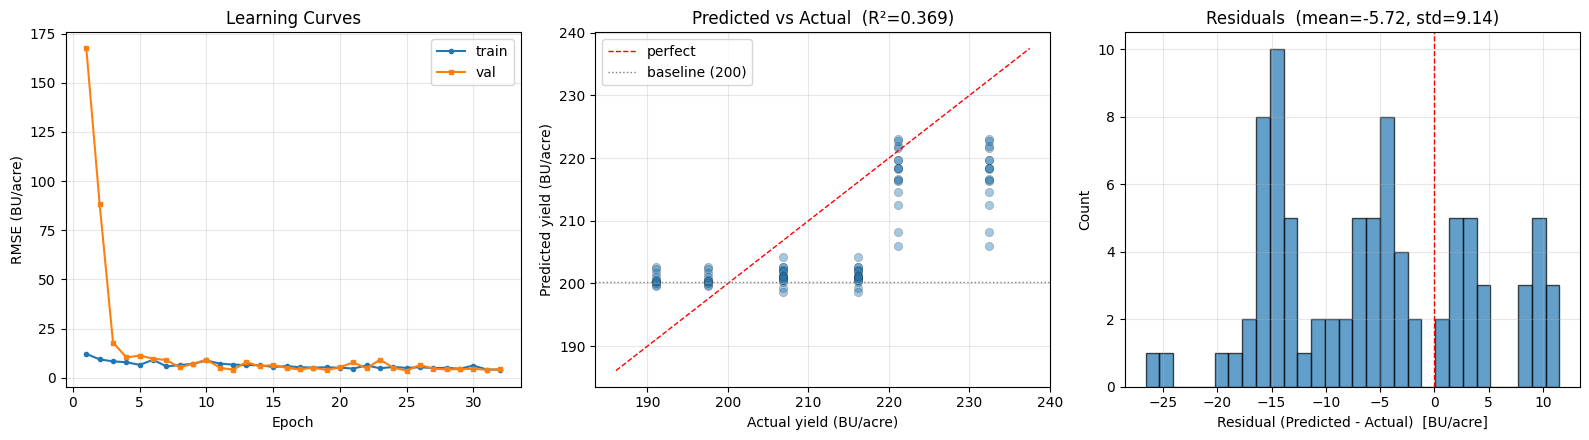

In [ ]:
# ---------------------------------------------------------------------------
# Diagnostic plots.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Learning curves — train vs val RMSE per epoch.
# A growing gap between the two curves signals overfitting.
ax = axes[0]
epochs = range(1, len(history["train_rmse"]) + 1)
ax.plot(epochs, history["train_rmse"], label="train", marker="o", markersize=3)
ax.plot(epochs, history["val_rmse"],   label="val",   marker="s", markersize=3)
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE (BU/acre)")
ax.set_title("Learning Curves")
ax.legend()
ax.grid(alpha=0.3)

# (2) Predicted vs actual scatter on test set.
# Points along the diagonal = perfect predictions.
# A flat horizontal cloud = model collapsed to predicting the mean.
ax = axes[1]
ax.scatter(y_true, y_pred, alpha=0.4, edgecolors="k", linewidths=0.3)
lims = [min(y_true.min(), y_pred.min()) - 5,
        max(y_true.max(), y_pred.max()) + 5]
ax.plot(lims, lims, "r--", linewidth=1, label="perfect")
# Also draw the baseline (constant predictor) as a horizontal line.
ax.axhline(baseline_pred, color="gray", linestyle=":", linewidth=1,
            label=f"baseline ({baseline_pred:.0f})")
ax.set_xlabel("Actual yield (BU/acre)")
ax.set_ylabel("Predicted yield (BU/acre)")
ax.set_title(f"Predicted vs Actual  (R²={test_r2:.3f})")
ax.legend()
ax.grid(alpha=0.3)

# (3) Residual histogram — errors should be roughly Gaussian and centered at 0.
# Skewed residuals = systematic bias (over- or under-predicting).
ax = axes[2]
residuals = y_pred - y_true
ax.hist(residuals, bins=30, edgecolor="k", alpha=0.7)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (Predicted - Actual)  [BU/acre]")
ax.set_ylabel("Count")
ax.set_title(f"Residuals  (mean={residuals.mean():.2f}, std={residuals.std():.2f})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8) Save checkpoint to `models/`

By default the next cell writes `models/multimodal_yield_<crop>.pt` under the repo root (next to `notebooks/`). Set env `CROPY_CKPT_DIR` if you want a different directory (e.g. Colab Drive).

In [ ]:
# ---------------------------------------------------------------------------
# Persist the trained model under <repo>/models/ (or CROPY_CKPT_DIR if set).
# ---------------------------------------------------------------------------
# What we save:
#   - model_state:      the actual weights (load with model.load_state_dict)
#   - yield_mean/std:   needed to denormalize predictions at inference time
#   - weather_dim:      needed to instantiate the right-sized model on load
#   - history:          training curves for later analysis
#   - test_metrics:     so we have the eval numbers without re-running
#   - hyperparameters:  model configuration so we remember what settings we used
# ---------------------------------------------------------------------------
import os
from pathlib import Path

# Saves to models/multimodal_yield_<crop>.pt under the repo root when cwd is
# the repo or the notebooks/ folder. Override: export CROPY_CKPT_DIR=/your/path
_cwd = Path.cwd().resolve()
if (_cwd / "notebooks").is_dir():
    _repo = _cwd
elif _cwd.name == "notebooks":
    _repo = _cwd.parent
else:
    _repo = _cwd

CKPT_DIR = os.environ.get("CROPY_CKPT_DIR", str(_repo / "models"))
os.makedirs(CKPT_DIR, exist_ok=True)

ckpt_path = os.path.join(CKPT_DIR, f"multimodal_yield_{CROP.lower()}.pt")
torch.save({
    "model_state":  model.state_dict(),
    "crop":         CROP,
    "yield_mean":   full_train_ds.yield_mean,
    "yield_std":    full_train_ds.yield_std,
    "weather_dim":  full_train_ds.weather_dim,
    "history":      history,
    "test_metrics": {
        "rmse":  test_rmse,
        "mae":   test_mae,
        "r2":    test_r2,
        "mape":  test_mape,
        "baseline_rmse": baseline_rmse,
        "baseline_mae": baseline_mae,
        "baseline_r2": baseline_r2,
    },
    "hyperparameters": {
        "NUM_EPOCHS": NUM_EPOCHS,
        "LEARNING_RATE": LEARNING_RATE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "EARLY_STOP_PAT": EARLY_STOP_PAT,
        "LR_PATIENCE": LR_PATIENCE,
        "BATCH_SIZE": BATCH_SIZE
    },
    "fips_train": FIPS_TRAIN,
    "fips_test":  FIPS_TEST,
    "years":      YEARS,
}, ckpt_path)

print(f"Saved checkpoint to: {ckpt_path}")
print(f"Test RMSE: {test_rmse:.2f} BU/acre  |  R²: {test_r2:.4f}")

Saved checkpoint to: /content/multimodal_yield_corn.pt
Test RMSE: 10.78 BU/acre  |  R²: 0.3685


## 11) Experiment Logging
Append the results of a training run into a growing Markdown file to keep track of all attempts.

In [ ]:
import os
from datetime import datetime
import pandas as pd
import torch

def log_experiment_to_md(checkpoint_path, log_file="training_log.md"):
    """
    Reads a saved PyTorch checkpoint and appends its metadata and
    training history to a Markdown file.
    """
    ckpt = torch.load(checkpoint_path, map_location=device)

    # Prepare history dataframe
    history_df = pd.DataFrame(ckpt.get("history", {}))
    history_df.index.name = "Epoch"
    history_df.index += 1

    metrics = ckpt.get("test_metrics", {})
    hparams = ckpt.get("hyperparameters", {})
    crop = ckpt.get("crop", "Unknown")
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Open the file in append mode ('a')
    with open(log_file, "a") as f:
        f.write(f"## Experiment: {crop} Yield Prediction - {now}\n\n")

        f.write("### Configuration\n")
        f.write(f"- **Crop**: {crop}\n")
        f.write(f"- **Train Counties FIPS**: {ckpt.get('fips_train', 'N/A')}\n")
        f.write(f"- **Test Counties FIPS**: {ckpt.get('fips_test', 'N/A')}\n")
        f.write(f"- **Years**: {ckpt.get('years', 'N/A')}\n\n")

        if hparams:
            f.write("### Hyperparameters\n")
            for k, v in hparams.items():
                f.write(f"- **{k}**: {v}\n")
            f.write("\n")

        f.write("### Test Results (Model vs Baseline)\n")
        for k, v in metrics.items():
            if isinstance(v, float):
                f.write(f"- **{k}**: {v:.4f}\n")
            else:
                f.write(f"- **{k}**: {v}\n")
        f.write("\n")

        f.write("### Epoch History\n")
        # to_markdown() creates a perfectly formatted Markdown table
        f.write(history_df.to_markdown())
        f.write("\n\n---\n\n")

    print(f"Successfully appended log to {log_file}")

# Let's log the checkpoint we saved earlier to a file in our Drive/working directory
log_path = os.path.join(CKPT_DIR, "training_log.md")
log_experiment_to_md(ckpt_path, log_path)

# Peek at the first few lines of the file to verify
with open(log_path, "r") as f:
    print("\n--- File Preview ---")
    print(f.read()[:800] + "\n... [File Continues]")

Successfully appended log to /content/training_log.md

--- File Preview ---
## Experiment: Corn Yield Prediction - 2026-04-25 21:30:27

### Configuration
- **Crop**: Corn
- **Train Counties FIPS**: ['17019', '17043', '19013', '19015', '26065', '18019', '39003']
- **Test Counties FIPS**: ['17115', '19163', '39101']
- **Years**: ['2021', '2022']

### Hyperparameters
- **NUM_EPOCHS**: 50
- **LEARNING_RATE**: 0.001
- **WEIGHT_DECAY**: 0.0001
- **EARLY_STOP_PAT**: 7
- **LR_PATIENCE**: 3
- **BATCH_SIZE**: 16

### Test Results (Model vs Baseline)
- **rmse**: 10.3813
- **mae**: 8.5715
- **r2**: 0.4144
- **mape**: 4.0016
- **baseline_rmse**: 18.5296
- **baseline_mae**: 15.6256
- **baseline_r2**: -0.8656

### Epoch History
|   Epoch |   train_rmse |   val_rmse |      lr |
|--------:|-------------:|-----------:|--------:|
|       1 |     13.4259  |   18.0201  | 0.001   |
|  
... [File Continues]
